<h1>Whisper-Based Voice Embedding Extraction Pipeline</h1>

This notebook implements a high-quality Whisper-based voice embedding extraction pipeline, optimized for Google Colab GPU execution and designed for multimodal fusion. It processes audio files from a specified dataset, extracts fixed-length voice embeddings using a pretrained Whisper Tiny model, and saves them to Google Drive along with labels, metadata, and visualizations (PCA and t-SNE).

<h2>1. Setup and Reproducibility</h2>

This section handles Google Drive mounting, installs required libraries, and sets random seeds for reproducibility.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install necessary libraries
!pip install transformers librosa soundfile scikit-learn matplotlib seaborn tqdm -qq

import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import random
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set random seeds for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

# Define constants
WHISPER_MODEL_NAME = "openai/whisper-tiny"
DATASET_ROOT = "/content/drive/MyDrive/DataSet_Voice"
OUTPUT_DIR_NAME = "Voice_Embeddings_Output"
OUTPUT_BASE_PATH = os.path.join("/content/drive/MyDrive", OUTPUT_DIR_NAME)

# Check for GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_BASE_PATH, exist_ok=True)
print(f"Output directory created: {OUTPUT_BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
Output directory created: /content/drive/MyDrive/Voice_Embeddings_Output


<h2>2. Audio Preprocessing Utilities</h2>

This section defines a helper function to load and preprocess audio files. It handles various formats (WAV, MP3, FLAC, OGG), converts to mono, resamples to Whisper's required sample rate (16 kHz), and safely manages corrupted or invalid files.

In [ ]:
WHISPER_SAMPLING_RATE = 16000

def load_and_preprocess_audio(filepath):
    """
    Loads an audio file, converts it to mono, and resamples it to the Whisper's required sampling rate.
    Handles various audio formats and corrupted files.

    Args:
        filepath (str): Path to the audio file.

    Returns:
        np.ndarray: Preprocessed audio waveform (mono, 16kHz) or None if error.
        int: Original sampling rate of the audio file or None if error.
    """
    try:
        # Librosa can handle various formats (WAV, MP3, FLAC, OGG) automatically
        audio, original_sr = librosa.load(filepath, sr=None, mono=True)

        # Resample only if necessary
        if original_sr != WHISPER_SAMPLING_RATE:
            audio = librosa.resample(y=audio, orig_sr=original_sr, target_sr=WHISPER_SAMPLING_RATE)

        return audio, original_sr
    except Exception as e:
        logging.warning(f"Skipping corrupted or invalid file: {filepath} - Error: {e}")
        return None, None

<h2>3. Whisper Model Loading and Embedding Extraction</h2>

This section loads the `openai/whisper-tiny` model and its processor. It also defines a function to extract mean-pooled encoder representations, which serve as fixed-length voice embeddings.

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq

# Load Whisper processor and model
# Using model.model.encoder to access the underlying transformer encoder
processor = AutoProcessor.from_pretrained(WHISPER_MODEL_NAME)
model = AutoModelForSpeechSeq2Seq.from_pretrained(WHISPER_MODEL_NAME).to(device)
model.eval()

def extract_whisper_encoder_embedding(audio_waveform, processor, model, device):
    """
    Consolidated helper for extracting mean-pooled encoder embeddings.
    """
    inputs = processor(audio_waveform, sampling_rate=WHISPER_SAMPLING_RATE, return_tensors="pt").input_features.to(device)
    with torch.no_grad():
        # Accessing the encoder via the 'model' attribute of the wrapper
        encoder_outputs = model.model.encoder(inputs)
        embedding = encoder_outputs.last_hidden_state.mean(dim=1).squeeze(0).cpu().numpy()
    return embedding

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

<h2>4. Dataset Iteration and Batch Processing</h2>

This section iterates through the `DataSet_Voice` directory, identifies audio files and their emotion labels, preprocesses them, and extracts Whisper embeddings. Files are processed in batches for efficiency on GPU. Corrupted files are skipped and logged.

In [ ]:
# Process files in batches for efficiency
BATCH_SIZE = 16
all_embeddings = []
all_label_indices = []
all_filepaths = []
all_original_labels = []
skipped_files_count = 0

# Ensure model is on device and in eval mode
model.to(device)
model.eval()

for i in tqdm(range(0, len(audio_files), BATCH_SIZE), desc="Extracting Embeddings"):
    batch_files = audio_files[i:i + BATCH_SIZE]
    batch_labels = labels[i:i + BATCH_SIZE]
    batch_waveforms = []
    batch_valid_indices = []

    for j, filepath in enumerate(batch_files):
        waveform, _ = load_and_preprocess_audio(filepath)
        if waveform is not None:
            batch_waveforms.append(waveform)
            batch_valid_indices.append(j)
        else:
            skipped_files_count += 1

    if not batch_waveforms:
        continue

    # Whisper processor MUST pad to 3000 frames for the encoder to function
    inputs = processor(
        batch_waveforms,
        sampling_rate=WHISPER_SAMPLING_RATE,
        return_tensors="pt",
        padding="max_length",
        truncation=True
    ).input_features.to(device)

    with torch.no_grad():
        # Accessing the underlying encoder directly
        encoder_outputs = model.model.encoder(inputs)
        # Mean pool across the temporal dimension (dim=1) for a fixed D-dim vector
        batch_embeddings = encoder_outputs.last_hidden_state.mean(dim=1).cpu().numpy()

    for k, idx_in_batch in enumerate(batch_valid_indices):
        all_embeddings.append(batch_embeddings[k])
        all_label_indices.append(label_to_idx[batch_labels[idx_in_batch]])
        all_filepaths.append(batch_files[idx_in_batch])
        all_original_labels.append(batch_labels[idx_in_batch])

    # Cleanup batch memory
    del inputs
    if device == 'cuda':
        torch.cuda.empty_cache()

# Prepare final arrays for fusion (ensure float32 for EfficientNet compatibility)
voice_embeddings = np.array(all_embeddings).astype('float32')
voice_labels = np.array(all_label_indices)

print(f"\nExtraction Complete. Successfully Processed: {len(voice_embeddings)}, Skipped: {skipped_files_count}")

Extracting Embeddings:   0%|          | 0/719 [00:00<?, ?it/s]


Extraction Complete. Successfully Processed: 11490, Skipped: 0


<h2>5. Validation Checks</h2>

This section performs several checks to ensure the integrity and consistency of the extracted data. It prints statistics about the embeddings, labels, and class distribution.

In [ ]:
print("\n--- Validation Checks ---")

# Embedding dimension
embedding_dim = voice_embeddings.shape[1]
print(f"Embedding dimension (D): {embedding_dim}")

# Number of classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")

# Class distribution
unique_labels, counts = np.unique(voice_labels, return_counts=True)
class_distribution = dict(zip([class_names[i] for i in unique_labels], counts))
print(f"Class distribution: {class_distribution}")

# Verify len(voice_embeddings) == len(voice_labels)
if len(voice_embeddings) == len(voice_labels):
    print("Verification successful: Length of embeddings matches length of labels.")
else:
    print("Verification FAILED: Length of embeddings does NOT match length of labels.")

# Print shapes
print(f"Shape of voice_embeddings: {voice_embeddings.shape}")
print(f"Shape of voice_labels: {voice_labels.shape}")

# Print class mappings
print("Class mappings:")
for idx, name in enumerate(class_names):
    print(f"  {idx}: {name}")


--- Validation Checks ---
Embedding dimension (D): 384
Number of classes: 7
Class distribution: {'angry': np.int64(1863), 'disgust': np.int64(1863), 'fear': np.int64(1863), 'happy': np.int64(1863), 'neutral': np.int64(1583), 'sad': np.int64(1863), 'surprise': np.int64(592)}
Verification successful: Length of embeddings matches length of labels.
Shape of voice_embeddings: (11490, 384)
Shape of voice_labels: (11490,)
Class mappings:
  0: angry
  1: disgust
  2: fear
  3: happy
  4: neutral
  5: sad
  6: surprise


<h2>6. Output Saving to Google Drive</h2>

This section saves the extracted voice embeddings, corresponding labels, class names, and a metadata CSV file to the `Voice_Embeddings_Output` folder in Google Drive.

In [ ]:
# Prepare metadata DataFrame
metadata_df = pd.DataFrame({
    'filepath': all_filepaths,
    'label': all_original_labels,
    'label_index': all_label_indices
})

# Save outputs
embeddings_path = os.path.join(OUTPUT_BASE_PATH, "voice_embeddings.npy")
labels_path = os.path.join(OUTPUT_BASE_PATH, "voice_labels.npy")
class_names_path = os.path.join(OUTPUT_BASE_PATH, "class_names.npy")
metadata_path = os.path.join(OUTPUT_BASE_PATH, "embedding_metadata.csv")

np.save(embeddings_path, voice_embeddings)
np.save(labels_path, voice_labels)
np.save(class_names_path, np.array(class_names))
metadata_df.to_csv(metadata_path, index=False)

print("\n--- Outputs Saved to Google Drive ---")
print(f"Voice embeddings saved to: {embeddings_path}")
print(f"Voice labels saved to: {labels_path}")
print(f"Class names saved to: {class_names_path}")
print(f"Embedding metadata saved to: {metadata_path}")


--- Outputs Saved to Google Drive ---
Voice embeddings saved to: /content/drive/MyDrive/Voice_Embeddings_Output/voice_embeddings.npy
Voice labels saved to: /content/drive/MyDrive/Voice_Embeddings_Output/voice_labels.npy
Class names saved to: /content/drive/MyDrive/Voice_Embeddings_Output/class_names.npy
Embedding metadata saved to: /content/drive/MyDrive/Voice_Embeddings_Output/embedding_metadata.csv


<h2>7. Visualization of Embeddings</h2>

This section generates 2D visualizations (PCA and t-SNE) of the extracted voice embeddings. Points are colored by their emotion class to help evaluate whether emotional clusters emerge from the Whisper embeddings. The plots are saved as PNG files to Google Drive.


--- Generating Visualizations ---


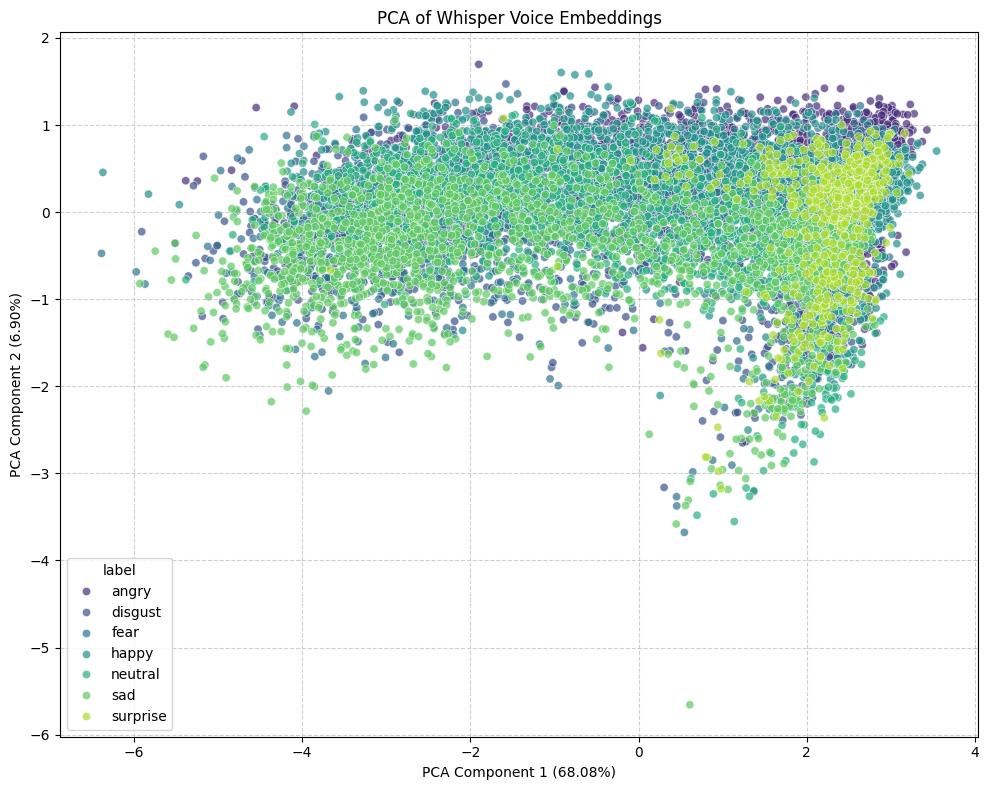

PCA visualization saved to: /content/drive/MyDrive/Voice_Embeddings_Output/pca_visualization.png


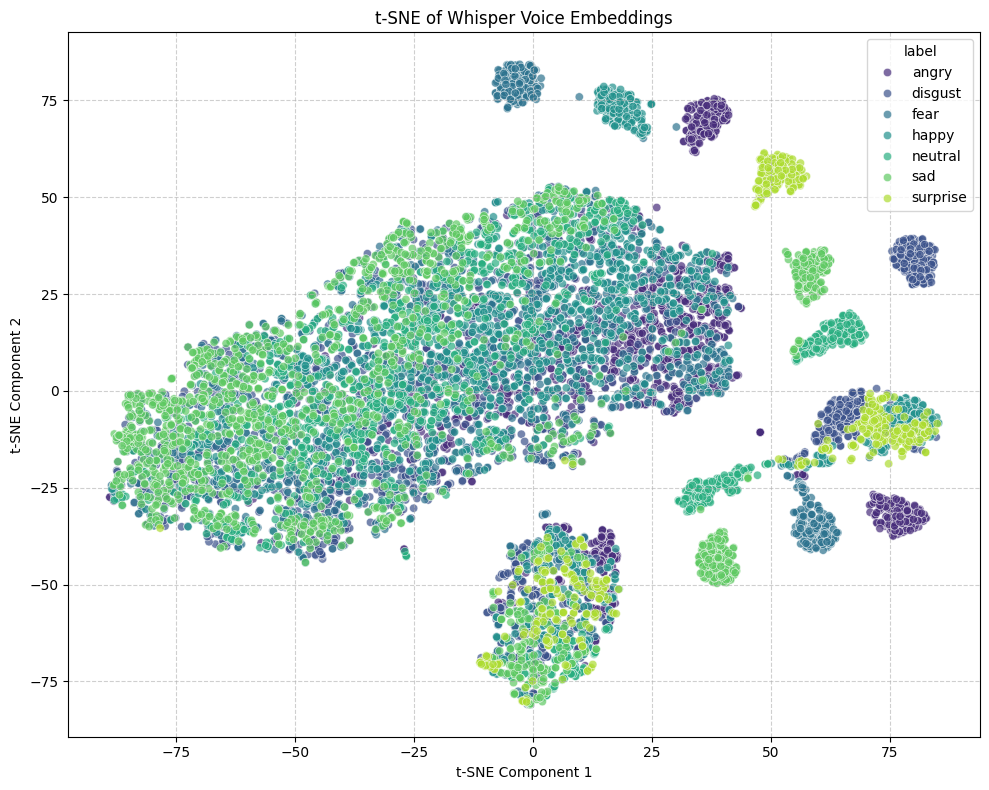

t-SNE visualization saved to: /content/drive/MyDrive/Voice_Embeddings_Output/tsne_visualization.png


In [ ]:
print("\n--- Generating Visualizations ---")

# 1. PCA Visualization
pca = PCA(n_components=2, random_state=SEED)
pca_result = pca.fit_transform(voice_embeddings)
pca_df = pd.DataFrame(data=pca_result, columns=['pca_1', 'pca_2'])
pca_df['label'] = [class_names[i] for i in voice_labels]

plt.figure(figsize=(10, 8))
sns.scatterplot(x='pca_1', y='pca_2', hue='label', data=pca_df, palette='viridis', legend='full', alpha=0.7)
plt.title('PCA of Whisper Voice Embeddings')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
pca_plot_path = os.path.join(OUTPUT_BASE_PATH, "pca_visualization.png")
plt.savefig(pca_plot_path)
plt.show()
print(f"PCA visualization saved to: {pca_plot_path}")

# 2. t-SNE Visualization
# It's recommended to reduce dimensions first with PCA for t-SNE on high-dimensional data
# or if the dataset is very large, for faster computation.
# Using default perplexity (30) and learning_rate (auto)
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, learning_rate='auto', init='pca', n_jobs=-1)
# Use smaller subset if t-SNE is too slow for very large datasets
# tsne_result = tsne.fit_transform(voice_embeddings[:5000]) # Example for subset
tsne_result = tsne.fit_transform(voice_embeddings)
tsne_df = pd.DataFrame(data=tsne_result, columns=['tsne_1', 'tsne_2'])
tsne_df['label'] = [class_names[i] for i in voice_labels]

plt.figure(figsize=(10, 8))
sns.scatterplot(x='tsne_1', y='tsne_2', hue='label', data=tsne_df, palette='viridis', legend='full', alpha=0.7)
plt.title('t-SNE of Whisper Voice Embeddings')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
tsne_plot_path = os.path.join(OUTPUT_BASE_PATH, "tsne_visualization.png")
plt.savefig(tsne_plot_path)
plt.show()
print(f"t-SNE visualization saved to: {tsne_plot_path}")

<h2>8. Conclusion and File Paths</h2>

This section confirms the completion of the embedding extraction and visualization process, and lists the exact Google Drive paths for all generated files.

In [ ]:
print("\n--- Process Complete ---")
print("All voice embeddings, labels, metadata, and visualizations have been generated and saved.")

print("\nExact Google Drive Paths of Generated Files:")
print(f"- Voice Embeddings: {embeddings_path}")
print(f"- Voice Labels: {labels_path}")
print(f"- Class Names: {class_names_path}")
print(f"- Embedding Metadata: {metadata_path}")
print(f"- PCA Visualization: {pca_plot_path}")
print(f"- t-SNE Visualization: {tsne_plot_path}")


--- Process Complete ---
All voice embeddings, labels, metadata, and visualizations have been generated and saved.

Exact Google Drive Paths of Generated Files:
- Voice Embeddings: /content/drive/MyDrive/Voice_Embeddings_Output/voice_embeddings.npy
- Voice Labels: /content/drive/MyDrive/Voice_Embeddings_Output/voice_labels.npy
- Class Names: /content/drive/MyDrive/Voice_Embeddings_Output/class_names.npy
- Embedding Metadata: /content/drive/MyDrive/Voice_Embeddings_Output/embedding_metadata.csv
- PCA Visualization: /content/drive/MyDrive/Voice_Embeddings_Output/pca_visualization.png
- t-SNE Visualization: /content/drive/MyDrive/Voice_Embeddings_Output/tsne_visualization.png


In [ ]:

print(voice_embeddings.shape)


print(voice_labels.shape)


print(np.unique(voice_labels))

(11490, 384)
(11490,)
[0 1 2 3 4 5 6]
